In [1]:
import optics_design_workbench.jupyter_utils as odw
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# restore default value for spherical lens radius
with odw.FreecadDocument() as doc:
  doc.Sphere.Radius = 10

# Opening and manipulating our .FCStd file

In [3]:
with odw.FreecadDocument() as doc:
  print(f'path: {doc.path()}')
  print(f'Sphere.Radius: {doc.Sphere.Radius}')
  print(f'result of .get method: {doc.Sphere.Radius.get()}')

path: ./GettingStarted.FCStd
Sphere.Radius: <FreecadProperty Sphere.Radius, value: 10.0 mm>
result of .get method: 10.0


In [4]:
with odw.FreecadDocument() as doc:
  doc.Sphere.Radius = 10.1

In [5]:
odw.openFreecadGui()

[Optics Design 23:30:21.517161] FreeCAD finished (exit code 0)


<RawFolder simulation-run-000209/ UID=dd9d16f7-deb6-462a-b287-ca8969fe47fe>
[Optics Design 23:30:48.829067] finding all result files in ./GettingStarted.OpticsDesign/raw/simulation-run-000209/**/*-hits.pkl


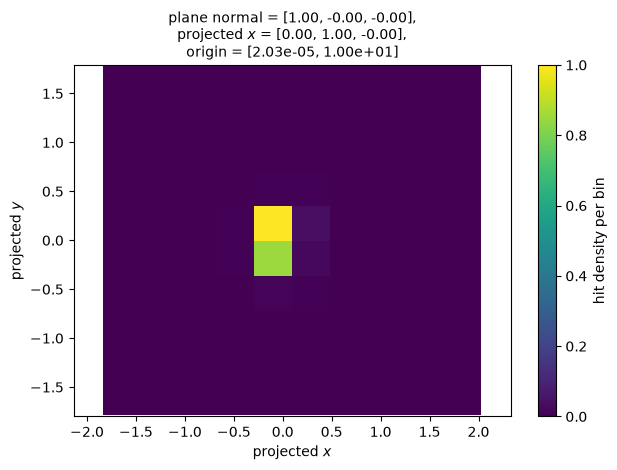

In [6]:
with odw.FreecadDocument() as doc:
  doc.OpticalSimulationSettings.EndAfterRays = 1e3
  raw = doc.runSimulation('true')
print(raw)
raw.loadHits().histogram().plot()

# Run simple parameter sweep

In [7]:
def calcFwhm(rawFolder):
  'calculate spot FWHM from a given simulation result folder'
  
  # load ray hit point cloud
  hits = rawFolder.loadHits()
  
  # setup list of fwhm results for different azimuth angles
  fwhmList = []

  # calculate polar histogram
  polarHist = hits.histogram(
        binCoords='polar', 
        bins=[np.arange(0, 2*np.pi, np.pi/2), 
              np.geomspace(1e-3, 5, 500)])

  # loop through azimuth angles if histogram
  phis, r, hists = polarHist.byAzimuth()
  for phi, dens in zip(phis, hists):
    
    # skip if no ray hit the bins we setup
    if max(dens) > 0:
      
      # perform and plot line fit of loglog data
      a, b = np.polyfit(np.log(r[dens>0])[:10], np.log(dens[dens>0])[:10], deg=1)
      rFit = np.geomspace(min(r), max(r[dens>10][:10]), 100)
      fitDens = np.exp( a*np.log(rFit)+b )
      
      # calculate, plot and store fwhm from fit in list
      try:
        fwhm = min(rFit[fitDens<=max(dens)/2])
        fwhmList.append(fwhm)
      # silently ignore errors in cases where fwhm is ill defined
      except ValueError:
        pass
  
  # return mean fwhm result
  return np.mean(fwhmList) if len(fwhmList) else np.nan

In [8]:
# prepare parameter and results list
radii = np.linspace(9, 11, 30)
fwhms = []

# open the .FCStd file
with odw.FreecadDocument() as doc:

  # setup progress tracking
  odw.setupProgressTracker(totalSimulations=len(radii))

  # establish settings we want to use for each simulation
  doc.OpticalSimulationSettings.EndAfterRays = 1e3

  # iterate over a range of lens radii
  for radius in radii:

    # update spherical lens radius
    doc.Sphere.Radius = radius

    # run a true-random simulation
    rawFolder = doc.runSimulation('true')
    
    # calculate the spot FWHM and append to result list
    fwhms.append( calcFwhm(rawFolder) ) 

simulations done 30/30
simulations ended after 8m 45s


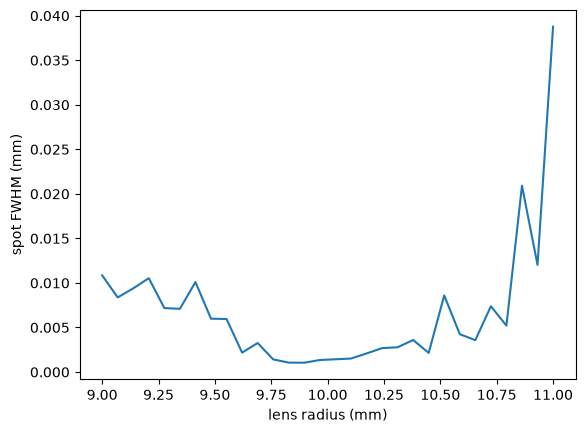

In [9]:
# plot fwhm vs. lens radius
plt.plot(radii, fwhms)
plt.xlabel('lens radius (mm)')
plt.ylabel('spot FWHM (mm)');

In [10]:
# set lens radius in the .FCStd file to the radius 
# corresponding to the smallest spot 
with odw.FreecadDocument() as doc:
  doc.Sphere.Radius = radii[np.argmin(fwhms)]

# Same optimization task using ParameterSweeper

In [11]:
def makeParameterDict(doc):
  return dict(
    r = doc.Sphere.Radius,
    z = doc.Sphere.Placement.Base.z,
  )

In [12]:
sweeper = odw.ParameterSweeper(makeParameterDict)

In [13]:
sweeper.set(r=10)

In [14]:
sweeper.parameters()

{'r': 10.0, 'z': -7.9}

In [15]:
sweeper.setBounds(r=(9,11))

In [16]:
# prepare parameter and results list
radii = np.linspace(9, 11, 30)
fwhms = []

for radius in radii:
    sweeper.set(r=radius)
    
    # calculate the spot FWHM and append to result list
    rawFolder = sweeper.runSimulation('true')
    fwhms.append( calcFwhm(rawFolder) ) 

/tmp/ipykernel_3644604/3890876157.py:24: RankWarning: Polyfit may be poorly conditioned
  a, b = np.polyfit(np.log(r[dens>0])[:10], np.log(dens[dens>0])[:10], deg=1)
/tmp/ipykernel_3644604/3890876157.py:24: RankWarning: Polyfit may be poorly conditioned
  a, b = np.polyfit(np.log(r[dens>0])[:10], np.log(dens[dens>0])[:10], deg=1)
/tmp/ipykernel_3644604/3890876157.py:24: RankWarning: Polyfit may be poorly conditioned
  a, b = np.polyfit(np.log(r[dens>0])[:10], np.log(dens[dens>0])[:10], deg=1)
/tmp/ipykernel_3644604/3890876157.py:24: RankWarning: Polyfit may be poorly conditioned
  a, b = np.polyfit(np.log(r[dens>0])[:10], np.log(dens[dens>0])[:10], deg=1)
/tmp/ipykernel_3644604/3890876157.py:24: RankWarning: Polyfit may be poorly conditioned
  a, b = np.polyfit(np.log(r[dens>0])[:10], np.log(dens[dens>0])[:10], deg=1)
/tmp/ipykernel_3644604/3890876157.py:24: RankWarning: Polyfit may be poorly conditioned
  a, b = np.polyfit(np.log(r[dens>0])[:10], np.log(dens[dens>0])[:10], deg=1)
/tmp

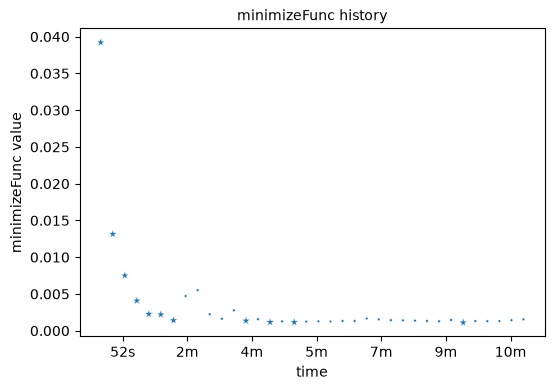

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 0.0011144428440814434
             x: [ 4.623e-01]
           nit: 16
          nfev: 37
 final_simplex: (array([[ 4.623e-01],
                       [ 4.624e-01]]), array([ 1.114e-03,  1.141e-03]))

In [17]:
sweeper.optimize(
  minimizeFunc=calcFwhm,
  parameters=['r'],
  simulationMode='true'
)

In [22]:
sweeper.parameters()

{'r': 9.9, 'z': -7.9, 'lensRadius': 9.9}

### Metaparameters

A *metaparameter* updates one or more regular parameters and may involve other calculations in between 

In [18]:
sweeper.addMetaParameters(
  lambda doc, lensRadius: dict(r=lensRadius, z=2-lensRadius)
)

In [19]:
sweeper.parameters()

{'r': 9.924609805156244, 'z': -7.9, 'lensRadius': nan}

In [20]:
sweeper.set(lensRadius=9.9)

In [21]:
sweeper.parameters()

{'r': 9.9, 'z': -7.9, 'lensRadius': 9.9}